# Flow Past a Cold Square with XLB (2D) — Unsteady, Passive Scalar Transport

This notebook brings together the unsteady **passive scalar transport** of temperature. Warm fluid flows down a channel, meets a cold square block, and carries a cold wake downstream.

**The setup:** fluid enters the left of a long channel at a parabolic (Poiseuille) profile and a uniform warm temperature. A square block sits near the inlet, held at a cold fixed temperature. 

**How the two solvers are coupled.** At every time step we do three things in order:

1. Advance the **flow** one step
2. Recover the **velocity field** from the flow populations
3. Advance the **temperature** one step, advected by that velocity

This is *one-way* coupling: the flow moves the heat, but the heat does not push back on the flow. That is the right model when temperature differences are too small to change the fluid's density appreciably. The main difference from the previous notebook is that the flow is now **unsteady** and the outflow is **open**.

## Prerequisites

Install XLB with JAX support. CPU works but GPU is recommended for this longer simulation. You should have read tutorials 01–04 to understand the basic patterns.

## Imports

In [1]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import xlb
import xlb.velocity_set
from xlb.compute_backend import ComputeBackend
from xlb.grid import grid_factory
from xlb.helper import omega_from_diffusivity
from xlb.operator.boundary_condition import (
    ExtrapolationOutflowBC,
    HalfwayBounceBackBC,
    RegularizedBC,
    ScalarDirichletBC,
    ScalarNeumannBC,
    ScalarOutflowBC,
)
from xlb.operator.macroscopic import Macroscopic, ZeroMoment
from xlb.operator.stepper import IncompressibleNavierStokesStepper, ThermalStepper
from xlb.precision_policy import PrecisionPolicy

FIG_DIR = Path("figures/flow_past_square_thermal_2d")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.figsize": (10, 5), "image.cmap": "RdBu_r"})

---
## Step 1 — Simulation parameters (higher Re for unsteady flow)

We pick **Re = 200** to ensure the flow becomes unsteady with clear vortex shedding. The **Péclet number Pe** is computed from the Reynolds and Prandtl numbers: Pe = Re × Pr. When Pr = ν/α = 1 (equal diffusion rates), the thermal boundary layer is comparable in thickness to the viscous one.

In [2]:
ny = 128
nx = int(3.0 * ny)  # long channel: give the thermal plume room to even out before the outlet
grid_shape = (nx, ny)

compute_backend = ComputeBackend.JAX
precision_policy = PrecisionPolicy.FP64FP64

flow_velocity_set = xlb.velocity_set.D2Q9(
    precision_policy=precision_policy,
    compute_backend=compute_backend,
)
thermal_velocity_set = xlb.velocity_set.D2Q5(
    precision_policy=precision_policy,
    compute_backend=compute_backend,
)

Re = 200.0
u_inlet = 0.05
square_side = int(ny / 12)

Pr = 0.71
Pe = Re * Pr

viscosity = u_inlet * square_side / Re
omega_flow = 1.0 / (3.0 * viscosity + 0.5)

diffusivity = u_inlet * square_side / Pe
# D2Q5 has cs^2 = 1/3, but pass the stencil so this stays correct if you switch to D3Q7
omega_thermal = omega_from_diffusivity(diffusivity, cs2=thermal_velocity_set)

print(f"Domain:           {grid_shape[0]} x {grid_shape[1]}")
print(f"Square side:      {square_side} cells")
print(f"Re:               {Re:.1f} (unsteady, vortex shedding expected)")
print(f"Pe:               {Pe:.1f}   (Pr = {Pr})")
print(f"Viscosity nu:     {viscosity:.6f} -> omega_flow    = {omega_flow:.4f}")
print(f"Diffusivity alpha:{diffusivity:.6f} -> omega_thermal = {omega_thermal:.4f}")

Domain:           384 x 128
Square side:      10 cells
Re:               200.0 (unsteady, vortex shedding expected)
Pe:               142.0   (Pr = 0.71)
Viscosity nu:     0.002500 -> omega_flow    = 1.9704
Diffusivity alpha:0.003521 -> omega_thermal = 1.9586


---
## Step 2 — Initialize XLB and create the grid

In [3]:
xlb.init(
    velocity_set=flow_velocity_set,
    default_backend=compute_backend,
    default_precision_policy=precision_policy,
)

grid = grid_factory(grid_shape, compute_backend=compute_backend)
print(f"Grid shape: {grid.shape}")

No GPU support is available; CPU fallback will be used.
Grid shape: (384, 128)


---
## Step 3 — Boundary indices

In [4]:
box = grid.bounding_box_indices()
box_no_edge = grid.bounding_box_indices(remove_edges=True)

inlet = box_no_edge["left"]
outlet = box_no_edge["right"]
walls = [box["bottom"][i] + box["top"][i] for i in range(flow_velocity_set.d)]
walls = np.unique(np.array(walls), axis=-1).tolist()

square_center_x = nx // 6  # near the inlet, leaving a long downstream stretch
square_center_y = ny // 2
half_side = square_side // 2

square_mask = (
    (np.arange(nx)[:, None] - square_center_x) ** 2 < (half_side + 0.5) ** 2
) & (
    (np.arange(ny)[None, :] - square_center_y) ** 2 < (half_side + 0.5) ** 2
)
square_indices_arr = np.where(square_mask)
square = [tuple(square_indices_arr[i].tolist()) for i in range(flow_velocity_set.d)]

print(f"Inlet nodes:  {len(inlet[0])}")
print(f"Outlet nodes: {len(outlet[0])}")
print(f"Wall nodes:   {len(walls[0])}")
print(f"Square nodes: {len(square[0])}")
print(f"Downstream length: {(nx - square_center_x) / square_side:.1f} square-sides")

Inlet nodes:  126
Outlet nodes: 126
Wall nodes:   768
Square nodes: 121
Downstream length: 32.0 square-sides


---
## Step 4 — Flow boundary conditions

In [5]:
def bc_inlet_profile():
    channel_height = float(grid_shape[1] - 1)
    u_peak = 1.5 * u_inlet

    def profile_jax():
        y = jnp.arange(grid_shape[1])
        u_x = jnp.maximum(
            0.0,
            4.0 * u_peak / channel_height**2 * (y * channel_height - y**2),
        )
        u_y = jnp.zeros_like(u_x)
        return jnp.stack([u_x, u_y])

    return profile_jax

bc_inlet = RegularizedBC("velocity", profile=bc_inlet_profile(), indices=inlet)
bc_outlet = ExtrapolationOutflowBC(indices=outlet)
bc_walls = HalfwayBounceBackBC(indices=walls)
bc_square = HalfwayBounceBackBC(indices=square)

flow_boundary_conditions = [bc_walls, bc_inlet, bc_outlet, bc_square]
print("Flow BCs registered")

registered bc RegularizedBC_300158161 with id 1
registered bc ExtrapolationOutflowBC_300157978 with id 2
registered bc HalfwayBounceBackBC_300028948 with id 3
WARNING! Assuming no-slip condition for BC type = HalfwayBounceBackBC!
registered bc HalfwayBounceBackBC_300130888 with id 4
WARNING! Assuming no-slip condition for BC type = HalfwayBounceBackBC!
Flow BCs registered


---
## Step 5 — Prepare the flow stepper

We build the flow stepper and the momentum-transfer operator now, but we do not run the flow on its own. Both solvers advance together in the coupled loop of Step 9.

In [6]:
from xlb.operator.force.momentum_transfer import MomentumTransfer

flow_stepper = IncompressibleNavierStokesStepper(
    grid=grid,
    boundary_conditions=flow_boundary_conditions,
    collision_type="BGK",
)

f_0, f_1, bc_mask_flow, missing_mask_flow = flow_stepper.prepare_fields()
momentum_transfer = MomentumTransfer(bc_square, compute_backend=compute_backend)

def drag_lift_coefficients(f_0, f_1, bc_mask, missing_mask):
    force = momentum_transfer(f_0, f_1, bc_mask, missing_mask)
    cd = 2.0 * force[0] / (u_inlet**2 * square_side)
    cl = 2.0 * force[1] / (u_inlet**2 * square_side)
    return float(cd), float(cl)

print("Flow stepper ready for coupled simulation.")

Warp 1.16.0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/rivas/Library/Caches/warp/1.16.0
Flow stepper ready for coupled simulation.


---
## Step 6 — Macroscopic operator

We need to recover the velocity field from the flow populations at every step, so we construct the `Macroscopic` operator once here rather than inside the loop.

In [7]:
macro = Macroscopic(
    compute_backend=compute_backend,
    precision_policy=precision_policy,
    velocity_set=flow_velocity_set,
)

print("Macroscopic operator initialized.")

Macroscopic operator initialized.


---
## Step 7 — Thermal boundary conditions

Now the temperature side:

- **Inlet (left):** `ScalarDirichletBC(value=1.0)` — warm fluid enters
- **Outlet (right):** `ScalarOutflowBC` — an **open** boundary, see below
- **Top/bottom walls:** `ScalarNeumannBC(flux=0.0)` — insulated or 'ScalarDirichletBC(value=0.5)` if you want a fixed wall temperature
- **Square:** `ScalarDirichletBC(value=0.0)` — the cold block

### Why the outlet is not a Neumann condition

It looks natural to write `ScalarNeumannBC(flux=0.0)` at the outlet: an outlet has zero
normal gradient, and `flux=0` is the zero-gradient condition. That is wrong, and it is the
single most destructive mistake you can make in this setup.

`ScalarNeumannBC` is bounce-back. Following Ginzburg's symmetric/antisymmetric split of the
boundary closure, bounce-back nulls the **antisymmetric** part, which imposes zero *total*
normal flux — advective plus diffusive. At a **solid wall** the fluid does not cross the
boundary, the advective part is already zero, and bounce-back correctly gives an adiabatic
wall. At an **outlet** the boundary normal is exactly the direction the fluid crosses, so
$\mathbf{c}_i\cdot\mathbf{u} \neq 0$ on the missing link and bounce-back reflects the
outgoing scalar straight back in. Against the equilibrium
$g^{eq}_i = w_i\,\phi\,(1 + \mathbf{c}_i\cdot\mathbf{u}/c_s^2)$ the reflected population is
wrong by

$$2\,w_i\,\phi\,\frac{\mathbf{c}_i\cdot\mathbf{u}}{c_s^2}$$

per node per step. That is a **source term sitting on the outlet**, not a zero-gradient
condition, and it drives the temperature out of its physical range within a few thousand
steps.

The rule to remember:

| Boundary | Correct scheme | XLB class |
|---|---|---|
| Wall, $u=0$, zero flux | bounce-back | `ScalarNeumannBC` |
| Wall, prescribed value | anti-bounce-back | `ScalarDirichletBC` |
| Open boundary, $u\cdot n \neq 0$ | extrapolation | `ScalarOutflowBC` |

### Corners

A node where two faces meet has two missing directions of different character, and a
single per-node condition cannot express both. The rule the cavity tutorial follows, and
the one the literature recommends, is that **Dirichlet wins over Neumann** at a corner: a
prescribed value is well posed, whereas a zero-flux condition at a corner has two competing
normals. So the inlet and outlet faces take the **full** bounding box and the adiabatic
walls use `remove_edges=True`, which keeps the walls away from the corners entirely.

> **Reference.** Ginzburg, I. (2005), *Generic boundary conditions for lattice Boltzmann
> models and their application to advection and anisotropic dispersion equations*,
> Adv. Water Resour. 28(11), 1196–1216. Yang, Z. (2013), *Lattice Boltzmann outflow
> treatments: convective conditions and others*, Comput. Math. Appl. 65(2), 160–171.

In [8]:
thermal_walls = [
    box_no_edge["bottom"][i] + box_no_edge["top"][i]
    for i in range(thermal_velocity_set.d)
]
thermal_walls = np.unique(np.array(thermal_walls), axis=-1).tolist()

thermal_inlet = box["left"]
thermal_outlet = box["right"]

bc_thermal_walls = ScalarDirichletBC(value=0.5, indices=thermal_walls)
# bc_thermal_walls = ScalarNeumannBC(flux=0.0, indices=thermal_walls)
bc_thermal_outlet = ScalarOutflowBC(indices=thermal_outlet)
bc_thermal_inlet = ScalarDirichletBC(value=1.0, indices=thermal_inlet)
bc_thermal_square = ScalarDirichletBC(value=0.0, indices=square)

# Order matters where index lists overlap: XLB resolves collisions with "last in the list
# wins" when it builds bc_mask, so the Dirichlet conditions go last.
thermal_boundary_conditions = [
    bc_thermal_walls,
    bc_thermal_outlet,
    bc_thermal_inlet,
    bc_thermal_square,
]

registered bc ScalarDirichletBC_279082421 with id 5
registered bc ScalarOutflowBC_300150752 with id 6
registered bc ScalarDirichletBC_296196362 with id 7
registered bc ScalarDirichletBC_300734408 with id 8


---
## Step 8 — Thermal stepper

In [9]:
thermal_stepper = ThermalStepper(
    grid=grid,
    boundary_conditions=thermal_boundary_conditions,
    velocity_set=thermal_velocity_set,
)


phi_init = 0.5 * np.ones((1, nx, ny))
phi_init[0, square[0], square[1]] = 0.0 # To ensure that inside square we have the correct boundary value.

g_0, g_1, bc_mask_thermal, missing_mask_thermal = thermal_stepper.prepare_fields(
    phi_init=phi_init
)
u_thermal, source_thermal = thermal_stepper.prepare_aux_fields()

---
## Step 9 — The coupled time loop

Each iteration advances the flow, reads the velocity out of it, and advances the
temperature with that velocity — in that order, so the scalar is always advected by the
velocity field of the step it belongs to.

### One extra step: repairing the velocity at the outlet

There is a subtlety in the hand-off between the two solvers that is easy to miss and hard
to debug, so it is worth stating plainly.

The flow's `ExtrapolationOutflowBC` owns the last column of the grid. It keeps the flow
solver stable and lets vortices leave cleanly, but it does **not** leave a meaningful
*macroscopic velocity* on that column: the populations there are extrapolation data, not a
converged hydrodynamic state. Recovering $\mathbf{u}$ from them gives

```
x = nx-2 :  u_x = 0.0490      <- real flow
x = nx-1 :  u_x = 0.000019    <- the outlet column
```

The flow solver never notices, because it never reads that velocity back. **The scalar
solver does.** To the thermal solver a column of near-zero velocity across the exit looks
like a stagnation wall: warm fluid convects in from upstream and has no way out, so the
scalar piles up against it until the run diverges. This, not the boundary conditions
themselves, was the largest single error in the coupled setup — fixing it took the run from
`T ∈ [−37, 314]` to `T ∈ [−1.0, 1.3]`.

The repair is one line: copy the velocity from the neighbouring interior column before
handing it to the scalar. Keep this in mind whenever you couple a second solver to an XLB
flow field — a boundary treatment that is perfectly good for the flow is not automatically
good as *input* to something else.

We record drag, lift and the temperature bounds at every step, and draw a snapshot every
`snapshot_interval` steps.

Step  23040: Cd= 5.4684, Cl=  4.6094, T in [-0.0003, 1.1141]


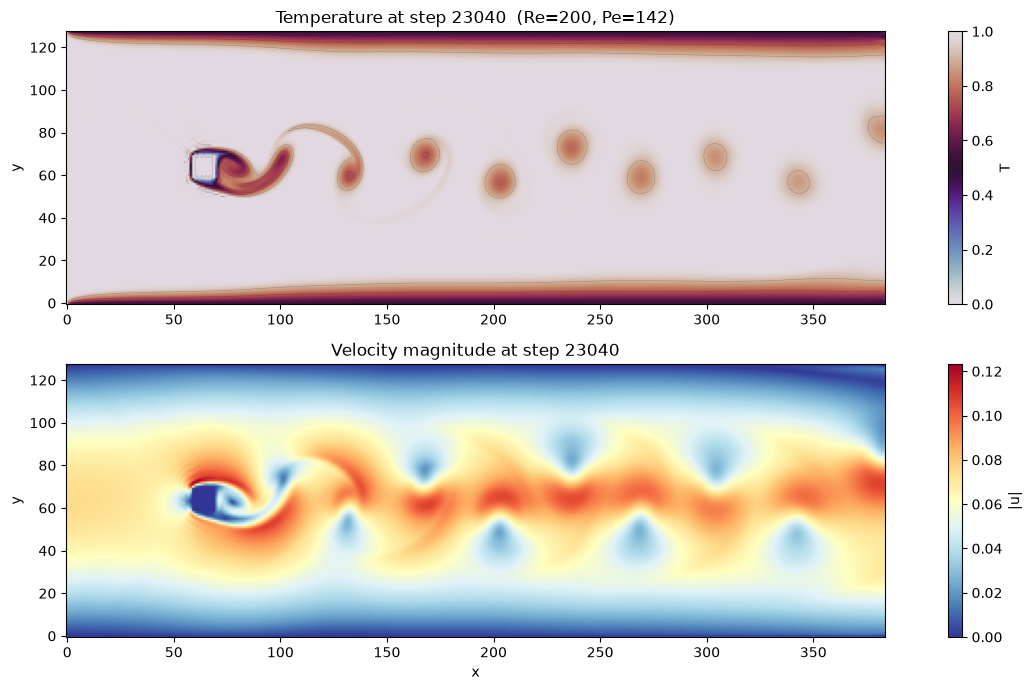

In [10]:
from IPython.display import clear_output as clc

# Size the run by flow-through time: how many steps for fluid to cross the domain once.
flow_pass = int(grid_shape[0] / u_inlet)
num_steps = 3 * flow_pass
snapshot_interval = max(1, flow_pass // 8)
# num_steps = 20000
# snapshot_interval = 5000

print(f"Flow-pass:   {flow_pass} steps (one domain crossing)")
print(f"num_steps:   {num_steps} ({num_steps / flow_pass:.0f} crossings)")
print(f"Snapshot every {snapshot_interval} steps\n")

snapshots_T = {}
cd_history = np.zeros(num_steps + 1)
cl_history = np.zeros(num_steps + 1)
tmin_history = np.zeros(num_steps + 1)
tmax_history = np.zeros(num_steps + 1)

zero_moment = ZeroMoment(
    velocity_set=thermal_velocity_set,
    precision_policy=precision_policy,
    compute_backend=compute_backend,
)

for step in range(num_steps + 1):
    # 1. Advance FLOW one step
    f_0, f_1 = flow_stepper(f_0, f_1, bc_mask_flow, missing_mask_flow, omega_flow, step)
    f_0, f_1 = f_1, f_0

    # 2. Extract the velocity field from the flow populations
    _, u_flow_current = macro(f_0)
    u_thermal = jnp.asarray(u_flow_current)

    # 2b. Repair the velocity on the outlet column before handing it to the scalar.
    #     ExtrapolationOutflowBC does not leave a usable macroscopic velocity on the
    #     column it owns: recovering u there gives essentially zero (u_x ~ 1e-5 against
    #     ~0.049 one cell upstream), because the populations on that column are
    #     extrapolation data rather than a converged hydrodynamic state.
    #
    #     The flow solver does not care -- it never reads that velocity back. The scalar
    #     solver does, and to it a zero-velocity column looks like a stagnation wall
    #     sitting across the exit: scalar convects in from upstream and cannot leave, so
    #     it piles up until the solution diverges. Copying the neighbouring column gives
    #     the scalar a physically sensible convection speed at the exit.
    u_thermal = u_thermal.at[:, -1, :].set(u_thermal[:, -2, :])

    # 3. Advance THERMAL one step, advected by that velocity
    g_0, g_1 = thermal_stepper(
        g_0, g_1, u_thermal, source_thermal,
        bc_mask_thermal, missing_mask_thermal,
        omega_thermal, step,
    )
    g_0, g_1 = g_1, g_0

    # Record diagnostics every step (cheap, and we want to catch instability early)
    cd, cl = drag_lift_coefficients(f_0, f_1, bc_mask_flow, missing_mask_flow)
    cd_history[step] = cd
    cl_history[step] = cl

    T_now = zero_moment(g_0)[0]
    tmin_history[step] = float(T_now.min())
    tmax_history[step] = float(T_now.max())

    if step % snapshot_interval == 0:
        T_snap = np.asarray(T_now)
        snapshots_T[step] = T_snap

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))

        # Clip the colour scale to the physical range but report the true extremes in
        # the title, so any overshoot is visible rather than silently saturated.
        im = ax1.imshow(T_snap.T, origin="lower", cmap="twilight", vmin=0, vmax=1)
        ax1.contour(T_snap.T, levels=8, colors="k", linewidths=0.3, alpha=0.3)
        ax1.set_title(f"Temperature at step {step}  (Re={Re:.0f}, Pe={Pe:.0f})")
        ax1.set_ylabel("y")
        fig.colorbar(im, ax=ax1, label="T")

        u_mag_snap = np.sqrt(np.asarray(u_thermal[0]) ** 2 + np.asarray(u_thermal[1]) ** 2)
        im = ax2.imshow(u_mag_snap.T, origin="lower", cmap="RdYlBu_r")
        ax2.set_title(f"Velocity magnitude at step {step}")
        ax2.set_xlabel("x")
        ax2.set_ylabel("y")
        fig.colorbar(im, ax=ax2, label="|u|")

        print(f"Step {step:6d}: Cd={cd:7.4f}, Cl={cl:8.4f}, "
              f"T in [{tmin_history[step]:.4f}, {tmax_history[step]:.4f}]")

        plt.tight_layout()
        plt.savefig(FIG_DIR / f"coupled_step_{step:06d}.png", dpi=100)
        plt.show()
        clc(wait=True)
        plt.close(fig)